In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.signal import savgol_filter
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from config import *

sns.set_style("darkgrid")

In [2]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.tail()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_300,...,historical_best_2500,is_historical_best_2500,group_count_2600,winrate_2600,historical_best_2600,is_historical_best_2600,group_count_2700,winrate_2700,historical_best_2700,is_historical_best_2700
1001886,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1834,False,145903,g8f6,0.284366,-0.788823,-0.174046,176.0,...,[d7d5],True,1755.0,0.458120,[d7d5],True,871.0,0.482204,[d7d5],True
1001887,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1835,True,145903,c2c4,-0.612085,-0.807181,-0.156649,173.0,...,[c1f4],True,1746.0,0.542383,[c1f4],True,876.0,0.541096,[c1f4],True
1001888,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,c7c6,1834,False,10250,e7e6,-0.845942,-0.715394,-0.169172,6.0,...,[d8d7],False,394.0,0.423858,"[b7b6, b8d7]",False,191.0,0.460733,"[b8d7, h7h6]",False
1001889,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/8/PPP1PPPP/RN1Q...,g1f3,1835,True,2449,e2e3,-0.495157,-0.109598,-0.132579,NaN,...,[c2c3],False,27.0,0.481481,"[b1c3, c2c3]",False,12.0,0.500000,"[b1c3, c2c3]",False
1001890,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/5N2/PPP1PPPP/RN...,c8g4,1834,False,156,c8f5,-1.001847,-0.036168,-0.159541,NaN,...,[c8g4],True,1.0,1.000000,[c8g4],True,1.0,1.000000,[c8g4],True


## Feature Coefficients

In [3]:
coefficients = pd.DataFrame(index=FEATURES)
p_values = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = sm.add_constant(subset[FEATURES])
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=0)
    coefficients[f'elo_{elo}'] = result.params
    p_values[f'elo_{elo}'] = result.pvalues

coefficients

In [5]:
# Significance (p-value < 0.05)
p_values < 0.05

,elo_300,elo_400,elo_500,elo_600,elo_700,elo_800,elo_900,elo_1000,elo_1100,elo_1200,...,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200,elo_2300,elo_2400,elo_2500,elo_2600,elo_2700
delta,True,True,True,False,True,True,True,True,True,True,...,True,True,False,True,True,False,True,True,True,True
fragility_score,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
variance,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


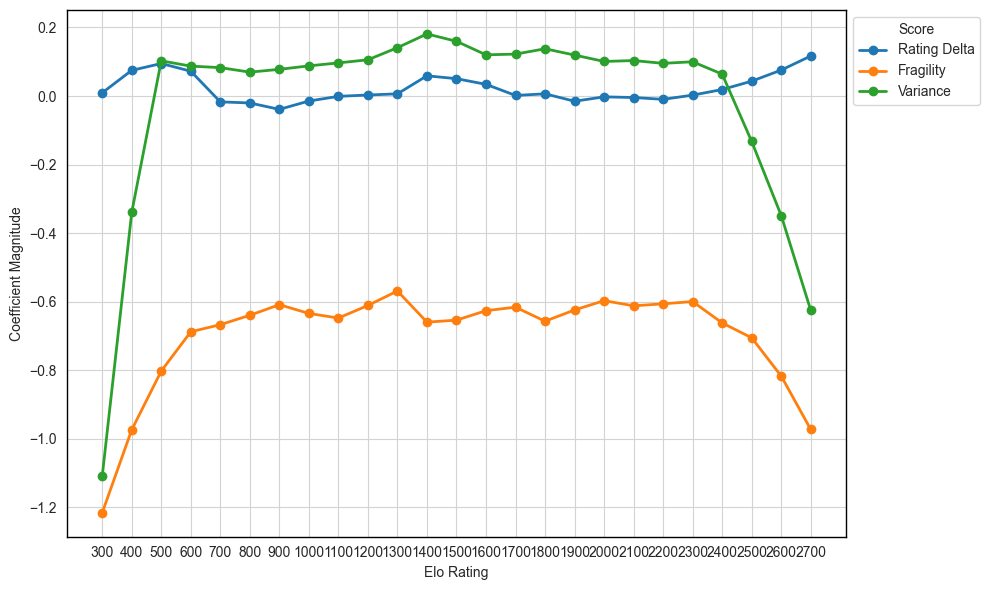

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(ELOS, y_smooth, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Coefficient Magnitude")
plt.xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_coefficients.pdf")
plt.show()

## Feature Importance

In [8]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances

,elo_300,elo_400,elo_500,elo_600,elo_700,elo_800,elo_900,elo_1000,elo_1100,elo_1200,...,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200,elo_2300,elo_2400,elo_2500,elo_2600,elo_2700
delta,0.178966,0.122242,0.158616,0.143035,0.154755,0.140853,0.131061,0.134765,0.162845,0.138072,...,0.137358,0.146222,0.127183,0.139286,0.144421,0.136128,0.149914,0.135784,0.157937,0.155969
fragility_score,0.548919,0.605207,0.488007,0.604024,0.598674,0.598035,0.603966,0.614083,0.603075,0.616978,...,0.578467,0.613246,0.630216,0.593978,0.609877,0.603940,0.614863,0.617085,0.580932,0.578522
variance,0.272116,0.272550,0.353377,0.252941,0.246570,0.261112,0.264973,0.251153,0.234079,0.244949,...,0.284175,0.240532,0.242601,0.266736,0.245702,0.259932,0.235223,0.247130,0.261131,0.265509


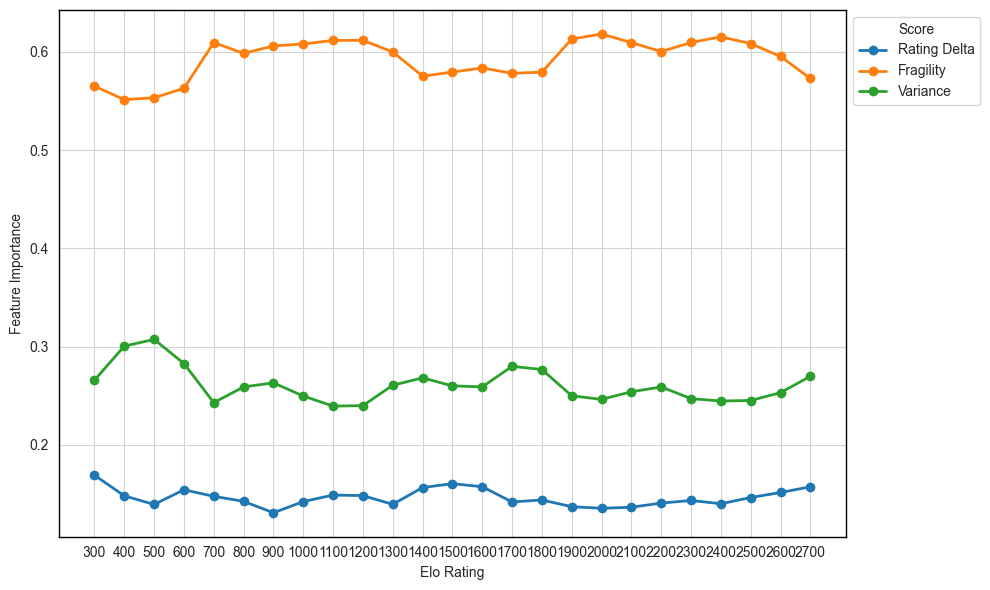

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    ax.plot(ELOS, y_smooth, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Feature Importance")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()

## Score Function and Move Recommendation

In [10]:
for elo in ELOS:
    score_col = f"score_{elo}"
    rec_col = f"recommended_move_{elo}"
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"
    elo_col = f"elo_{elo}"
    group_count_col = f"group_count_{elo}"
    hist_col = f"historical_best_{elo}"

    # Score function
    df[score_col] = (
            coefficients.loc["delta", elo_col] * df["delta"] +
            coefficients.loc["fragility_score", elo_col] * df["fragility_score"] +
            coefficients.loc["variance", elo_col] * df["variance"]
    )

    # Determine the recommended move per FEN based on the score
    idx_best_score = df.groupby("fen")[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best_score, ["fen", "next_move"]].set_index("fen")["next_move"]
    df[rec_col] = df["fen"].map(recommended)

    # Compare recommendations and engine move with historical best
    df[is_best_col] = df.apply(lambda r: r[rec_col] in r[hist_col], axis=1).astype('boolean')
    df[is_engine_col] = df.apply(lambda r: r["engine_move"] in r[hist_col], axis=1).astype('boolean')

    # Mask out positions with too few samples or missing data
    invalid_mask = (
            (df[group_count_col] < MIN_SAMPLES_PER_GROUP) |
            (df[group_count_col].isna())
    )
    df.loc[invalid_mask, [is_best_col, is_engine_col]] = pd.NA

    # Exclude rows where engine move is not among the observed moves for that position
    valid_moves_per_fen = df.groupby("fen")["next_move"].agg(set).to_dict()
    df["engine_valid_move"] = df.apply(
        lambda row: row["engine_move"] in valid_moves_per_fen.get(row["fen"], set()),
        axis=1
    )
    df.loc[~df["engine_valid_move"], [is_engine_col]] = pd.NA
    df.drop(columns="engine_valid_move", inplace=True)

In [11]:
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'


# TEST

In [12]:
results = []
grouped = df.groupby("fen").first().reset_index()

for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"

    avg_is_best = grouped[is_best_col].mean()
    avg_is_engine_best = grouped[is_engine_col].mean()

    results.append({
        "elo": elo,
        "avg_is_best": avg_is_best,
        "avg_is_engine_best": avg_is_engine_best
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_engine_best
elo,,
300,0.500000,0.000000
400,0.181818,0.222222
500,0.347826,0.300000
600,0.438356,0.366667
700,0.573864,0.547445
800,0.644068,0.584906
900,0.710396,0.660714
1000,0.729508,0.668750
1100,0.750958,0.680352


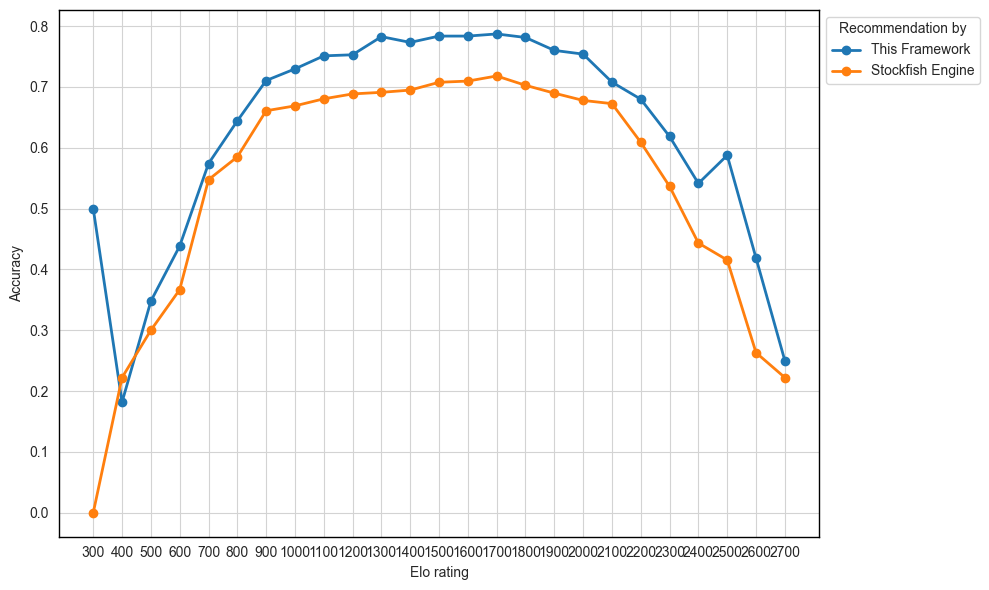

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for col in results.columns:
    if col == "avg_is_best":
        label = "This Framework"
    else:
        label = "Stockfish Engine"
    ax.plot(results.index, results[col].values, marker='o', linewidth=2, label=label)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Accuracy")
ax.set_xticks(results.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Recommendation by",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/prediction_accuracy.pdf")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Feature engineering
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]

target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

for y_feature in target_columns:
    print(f"{y_feature}:")
    df_reg = df[pd.notna(df[y_feature])]  # Remove NaN values

    # Ensure we have both classes (True and False) in the target variable
    if df_reg[y_feature].nunique() < 2:
        print("Skipping due to only one class in the target variable.")
        continue

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    # Logistic Regression
    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

    # XGBoost
    xgb_model = XGBClassifier()
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost Accuracy: {acc_xgb * 100:.1f} %")
    print()


is_best_300:
Logistic Regression Accuracy: 100.0 %
XGBoost Accuracy: 100.0 %

is_engine_best_300:
Skipping due to only one class in the target variable.
is_best_400:
Logistic Regression Accuracy: 95.0 %
XGBoost Accuracy: 100.0 %

is_engine_best_400:
Logistic Regression Accuracy: 100.0 %
XGBoost Accuracy: 100.0 %

is_best_500:
Logistic Regression Accuracy: 88.0 %
XGBoost Accuracy: 100.0 %

is_engine_best_500:
Logistic Regression Accuracy: 72.7 %
XGBoost Accuracy: 100.0 %

is_best_600:
Logistic Regression Accuracy: 89.0 %
XGBoost Accuracy: 100.0 %

is_engine_best_600:
Logistic Regression Accuracy: 95.6 %
XGBoost Accuracy: 99.8 %

is_best_700:
Logistic Regression Accuracy: 83.9 %
XGBoost Accuracy: 100.0 %

is_engine_best_700:
Logistic Regression Accuracy: 86.0 %
XGBoost Accuracy: 100.0 %

is_best_800:
Logistic Regression Accuracy: 81.7 %
XGBoost Accuracy: 100.0 %

is_engine_best_800:
Logistic Regression Accuracy: 89.5 %
XGBoost Accuracy: 99.9 %

is_best_900:
Logistic Regression Accuracy: 

# stacked linechart

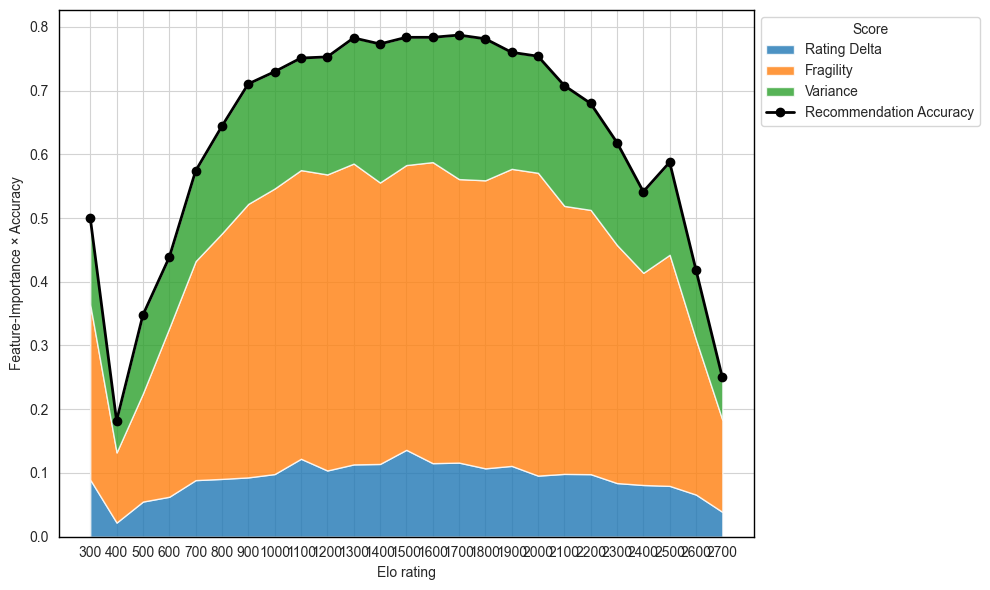

In [16]:
import matplotlib.pyplot as plt

# 1. Spaltennamen von 'importances' in Integer-Elo umwandeln,
#    falls sie das Format "elo_1000", "elo_1100" o. Ä. haben.
#    Beispiel: "elo_1000" → 1000
if importances.columns.dtype == object:
    importances.columns = (
        importances.columns
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 2. Index von 'results' ebenfalls in Integer-Elo umwandeln,
#    falls er z. B. "elo_1000", "elo_1100" o. Ä. enthält.
if results.index.dtype == object:
    results.index = (
        results.index
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 3. Transponiere 'importances', sodass jede Zeile eine Elo-Stufe ist,
#    und reindexiere auf dieselben Elo-Werte wie 'results'.
fi_df = importances.T.reindex(results.index).fillna(0)

# 4. Hole die Framework-Accuracy („avg_is_best“) als Array
y_acc = results["avg_is_best"].reindex(fi_df.index).fillna(0).values

# 5. Berechne für jedes Feature den Beitrag: feature_importance × accuracy
feature_arrays = []
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}
for feat in FEATURES:
    arr = fi_df[feat].values * y_acc
    feature_arrays.append(arr)

# 6. Zeichne das gestapelte Flächen-Diagramm unterhalb der Accuracy-Linie
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

ax.stackplot(
    fi_df.index,
    *feature_arrays,
    labels=[feature_labels[f] for f in FEATURES],
    alpha=0.8
)
ax.plot(
    fi_df.index,
    y_acc,
    color="black",
    marker="o",
    linewidth=2,
    label="Recommendation Accuracy"
)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Feature-Importance × Accuracy")
ax.set_xticks(fi_df.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()